In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [2]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

In [3]:
df.drop("Loan_ID", axis=1, inplace=True)
for col in df.columns:

    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])

    else:
        df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [4]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

y = y.map({
    "Y": 1,
    "N": 0
})

X = pd.get_dummies(X, drop_first=True)

X.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 14)
Testing data: (123, 14)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
logistic = LogisticRegression()

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [8]:
models = {
    "Logistic Regression": logistic,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    roc_auc = roc_auc_score(y_test, probability)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

In [9]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108,0.851393
1,Decision Tree,0.845528,0.823529,0.988235,0.898396,0.706037
2,Random Forest,0.845528,0.858696,0.929412,0.892655,0.804644


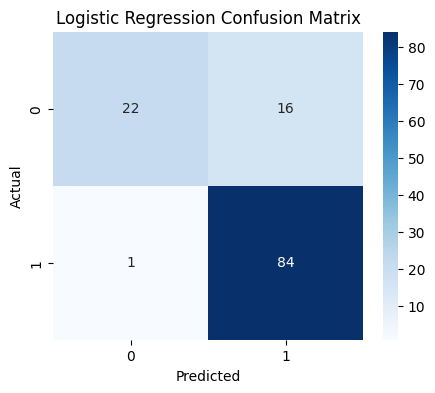

In [10]:
logistic_pred = logistic.predict(X_test)

cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# CONCLUSION

# We compared Logistic Regression, Decision Tree and Random Forest.

# Logistic Regression performed the best.

# It achieved around 86% accuracy and 91% F1-score.

# It also had very high recall of around 99%.

# Therefore, Logistic Regression is selected as the best model
# because it gives the best overall balance of Accuracy,
# Precision, Recall and F1-score.